# **1. Perkenalan Dataset**


**Sumber Dataset**:  
  Dataset yang digunakan adalah Diabetes Prediction Dataset dari Kaggle. Dataset ini berisi data medis dan demografis dari 100.000 pasien untuk memprediksi status diabetes mereka. Target variabel dalam dataset ini adalah kolom diabetes (0: Tidak Diabetes, 1: Diabetes).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
dataset_path = "diabetes_prediction_dataset.csv"
df = pd.read_csv(dataset_path)

# Mengintip 5 data teratas
print(f"Dimensi data: {df.shape}")
print("\n5 Data Teratas:")
df.head()

Dimensi data: (100000, 9)

5 Data Teratas:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

--- Jumlah Missing Values Per Kolom ---
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level 

/tmp/ipykernel_454/3714598461.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diabetes', palette='Set2')


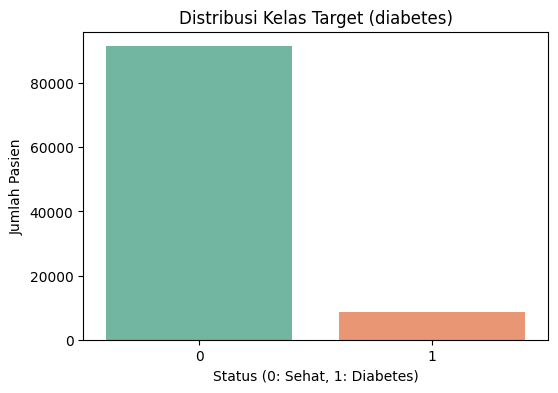


Nilai unik pada kolom gender: ['Female' 'Male' 'Other']
Nilai unik pada kolom smoking_history: ['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [3]:
# 1. Memeriksa tipe data dan missing values secara eksplisit
print("--- Informasi Struktur Data ---")
df.info()

print("\n--- Jumlah Missing Values Per Kolom ---")
print(df.isnull().sum())

# 2. Visualisasi Distribusi Target (Kolom 'diabetes')
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diabetes', palette='Set2')
plt.title("Distribusi Kelas Target (diabetes)")
plt.xlabel("Status (0: Sehat, 1: Diabetes)")
plt.ylabel("Jumlah Pasien")
plt.show()

# 3. Memeriksa nilai unik pada fitur kategorikal
print("\nNilai unik pada kolom gender:", df['gender'].unique())
print("Nilai unik pada kolom smoking_history:", df['smoking_history'].unique())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
def kriteria_preprocessing(df_input):
    df_clean = df_input.copy()

    # 1. Menghapus data duplikat jika ada (Penting untuk pembersihan data)
    df_clean = df_clean.drop_duplicates()

    # 2. Encoding Data Kategorikal menggunakan Manual Mapping
    gender_map = {'Female': 0, 'Male': 1, 'Other': 2}
    smoking_map = {'No Info': 0, 'never': 1, 'former': 2, 'current': 3, 'not current': 4, 'ever': 5}

    df_clean['gender'] = df_clean['gender'].map(gender_map)
    df_clean['smoking_history'] = df_clean['smoking_history'].map(smoking_map)

    # 3. Memisahkan Fitur (X) dan Target (y)
    # Target variabel di dataset ini bernama 'diabetes'
    X = df_clean.drop(columns=['diabetes'])
    y = df_clean['diabetes']

    # 4. Standarisasi Fitur Numerik (Scaling)
    # Fitur yang di-scale: age, bmi, HbA1c_level, blood_glucose_level
    numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

    scaler = StandardScaler()
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

    # 5. Menggabungkan kembali menjadi dataset yang bersih dan siap pakai
    df_ready = pd.concat([X, y.reset_index(drop=True)], axis=1)

    return df_ready

# Eksekusi fungsi preprocessing pada data eksperimen kamu
df_processed = kriteria_preprocessing(df)

# Menyimpan hasilnya menjadi file siap latih untuk Kriteria 2
df_processed.to_csv("diabetes_preprocessing.csv", index=False)
print("Data Preprocessing Selesai! File 'diabetes_preprocessing.csv' telah dibuat.")
print(f"Dimensi data setelah dibersihkan: {df_processed.shape}")

Data Preprocessing Selesai! File 'diabetes_preprocessing.csv' telah dibuat.
Dimensi data setelah dibersihkan: (99731, 9)
